<a href="https://colab.research.google.com/github/fhnribeiro/MVP_ML_-_Analytics/blob/main/Template_MVP_ML_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Template — MVP: *Machine Learning & Analytics*
**Autor:** _SEU NOME AQUI_  

**Data:** 27/08/2025

**Matrícula:** 2025000

**Dataset:** Ex: [Iris Dataset](https://archive.ics.uci.edu/dataset/53/iris)

> **Importante:**
A estrutura base deste notebook pode servir como um guia inicial para desenvolver suas análises, já que contempla grande parte das sugestões do checklist apresentado no enunciado do MVP. Entretanto, é importante destacar que esta estrutura é apenas um ponto de partida: poderão ser necessárias etapas e análises adicionais além das aqui exemplificadas.

> O essencial é garantir profundidade nas discussões e análises, construindo um storytelling consistente que explore os principais conceitos e técnicas vistos nas aulas da Sprint de Machine Learning & Analytics.

> Lembre-se: não existe uma receita pronta. A ordem e as seções detalhadas abaixo são apenas sugestões. O problema escolhido e a história que você deseja contar devem guiar, em grande parte, a forma final do seu trabalho.

---



## ✅ Checklist do MVP (o que precisa conter)
- [ ] **Problema definido** e contexto de negócio
- [ ] **Carga e preparação** dos dados (sem vazamento de dados)
- [ ] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [ ] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [ ] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [ ] **Otimização de hiperparâmetros**
- [ ] **Avaliação** com **métricas adequadas** e discussão de limitações
- [ ] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [ ] **Pipelines reprodutíveis** (sempre que possível)


## 1. Escopo, objetivo e definição do problema
**Contexto:** O dataset Adult (Census Income) contém informações demográficas e socioeconômicas de pessoas nos EUA, coletadas pelo censo. O objetivo clássico é prever se uma pessoa ganha mais de 50 mil dólares por ano, a partir de atributos como idade, escolaridade, ocupação, sexo, raça, entre outros.

- **Tipo de tarefa:** Classificação binária (renda >50K ou <=50K)
- **Área de aplicação:** Dados tabulares, análise socioeconômica
- **Valor para o negócio/usuário:** Permite identificar perfis de renda, apoiar políticas públicas, detectar possíveis vieses e desigualdades, e serve como benchmark para técnicas de Machine Learning.

---

## 1.1 Respostas às dúvidas do template
- **Problema definido:** Prever se uma pessoa ganha mais de 50K/ano com base em atributos do censo.
- **Contexto de negócio:** Políticas públicas, análise de renda, segmentação socioeconômica.
- **Tipo de tarefa:** Classificação binária.
- **Área de aplicação:** Dados tabulares, análise de dados sociais.
- **Valor:** Benchmark de ML, análise de desigualdade, apoio à tomada de decisão.

### 2. Reprodutibilidade e ambiente
- **Bibliotecas principais:** numpy, pandas, matplotlib, scikit-learn
- **Ambiente sugerido:** Python 3.8+ (funciona em Google Colab, Jupyter, VSCode)
- **Seeds fixas:** Para garantir reprodutibilidade dos resultados, a seed global foi definida como 42 para numpy e random. Isso garante que divisões de dados, inicialização de modelos e sorteios sejam sempre iguais a cada execução.
- **Observação:** Para frameworks como PyTorch ou TensorFlow, também é recomendado fixar as seeds específicas desses frameworks.
- **Dependências extras:** Instale apenas pacotes necessários para evitar problemas de ambiente e facilitar a correção/revisão do projeto.

Exemplo de ambiente mínimo:
- Python >= 3.8
- numpy
- pandas
- matplotlib
- scikit-learn

In [4]:
# === Setup básico e reprodutibilidade ===
import os, random, time, sys, math
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score)

from sklearn.model_selection import StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Para frameworks que suportam seed adicional (ex.: PyTorch/TensorFlow), documente aqui:
# import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
# import tensorflow as tf; tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

Python: 3.13.7
Seed global: 42



### 2.1 Dependências (opcional)
Instale pacotes extras se necessário. **Mantenha o projeto enxuto** para facilitar a correção.


In [5]:

# Exemplo: descomente o que precisar
# !pip install -q scikit-learn imbalanced-learn xgboost lightgbm catboost optuna
# !pip install -q pandas-profiling ydata-profiling
# !pip install -q matplotlib seaborn plotly
# !pip install -q statsmodels pmdarima


### 2.2 Funções python (opcional)
Defina, se necessário, funções em Python para reutilizar seu código e torná-lo mais organizado. Essa é uma boa prática de programação que facilita a leitura, manutenção e evolução do seu projeto.

In [6]:
def evaluate_classification(y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")
    auc = roc_auc_score(y_true, proba[:,1]) if (proba is not None and proba.shape[1]==2) else np.nan
    return {"accuracy": acc, "f1_weighted": f1w, "roc_auc": auc}

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

def evaluate_clustering(X_original, model):
    # Silhouette requer >1 cluster e dados transformados
    try:
        if hasattr(model.named_steps["pre"], "transform"):
            X_emb = model.named_steps["pre"].fit_transform(X_original)  # cuidado: apenas para demo
        else:
            X_emb = X_original
        labels = model.named_steps["model"].fit_predict(X_emb)
        sil = silhouette_score(X_emb, labels)
        return {"silhouette": sil}
    except Exception as e:
        return {"silhouette": np.nan, "erro": str(e)}

## 3. Dados: carga, entendimento e qualidade
**Origem dos dados:**
- O dataset Adult (Census Income) está disponível publicamente no UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/2/adult
- Os dados foram extraídos do censo dos EUA de 1994.

**Dicionário de variáveis (principais):**
- `age`: idade
- `workclass`: tipo de emprego
- `fnlwgt`: peso amostral
- `education`: nível de escolaridade
- `education-num`: anos de estudo
- `marital-status`: estado civil
- `occupation`: ocupação
- `relationship`: relação familiar
- `race`: raça
- `sex`: sexo
- `capital-gain`: ganho de capital
- `capital-loss`: perda de capital
- `hours-per-week`: horas trabalhadas por semana
- `native-country`: país de origem
- `income`: alvo (<=50K ou >50K)

**Licença/ética:**
- O dataset é de domínio público e amplamente utilizado para fins educacionais e de pesquisa.
- **Atenção:** O uso de variáveis sensíveis (raça, sexo) exige cuidado para evitar reforço de vieses e garantir discussões éticas sobre fairness e impacto social.

**Evite vazamento de dados:**
- Não utilize variáveis derivadas do target ou informações do futuro na modelagem.

In [7]:
# === Carga dos dados ===

# Carregar o dataset Adult (Census Income) diretamente do GitHub
url = 'https://raw.githubusercontent.com/fhnribeiro/MVP_ML_-_Analytics/main/adult.csv'
df = pd.read_csv(url, na_values='?')
df.head()

# Observação: O arquivo pode não ter nomes de colunas. Se necessário, defina-os manualmente conforme o dicionário de variáveis.


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [8]:
# === Verificações iniciais ===
display(df.sample(5))
print("\nFormato:", df.shape)
print("\nTipos:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())
print("\nValores únicos por coluna:")
print(df.nunique())


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
14160,29,Private,280618,Some-college,10,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,<=50K
27048,19,Private,439779,Some-college,10,Never-married,Sales,Own-child,White,Male,0,0,15,United-States,<=50K
28868,28,Private,204734,Some-college,10,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,40,United-States,<=50K
5667,35,Private,107991,11th,7,Never-married,Sales,Not-in-family,White,Male,0,0,45,United-States,<=50K
7827,20,Private,54152,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,NaN,<=50K



Formato: (32561, 15)

Tipos:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

Valores ausentes por coluna:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Valores únicos por coluna:
age                  73
workclass             8
fnlwgt            21648
education            16
education.num        16
marital.status        7
occupation           


### 3.1 Análise exploratória resumida (EDA)
**TODO:** inclua gráficos e tabelas essenciais para entender o problema e levantar hipóteses.  
Evite EDA muito extensa — foque no que afeta as decisões de modelagem.


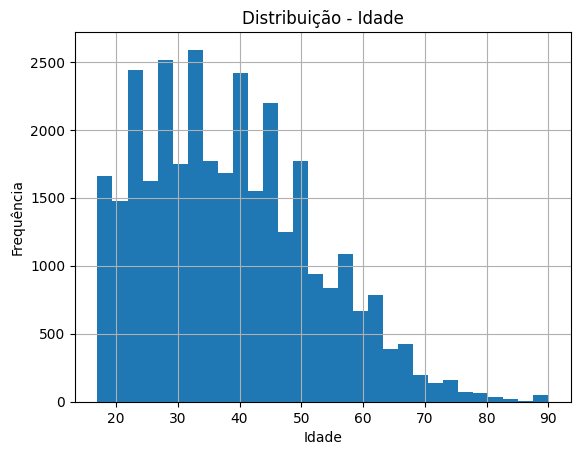

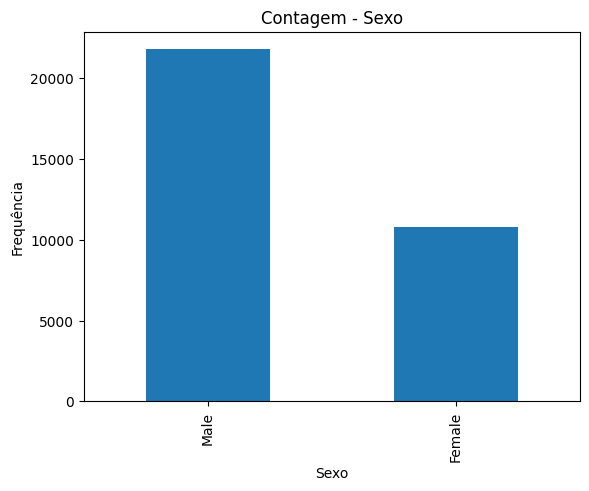

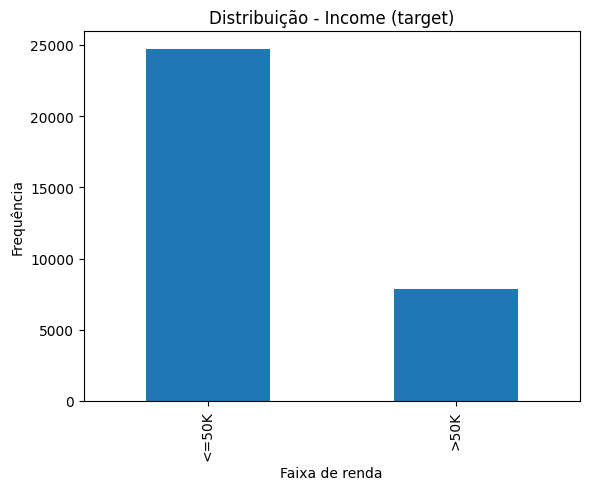

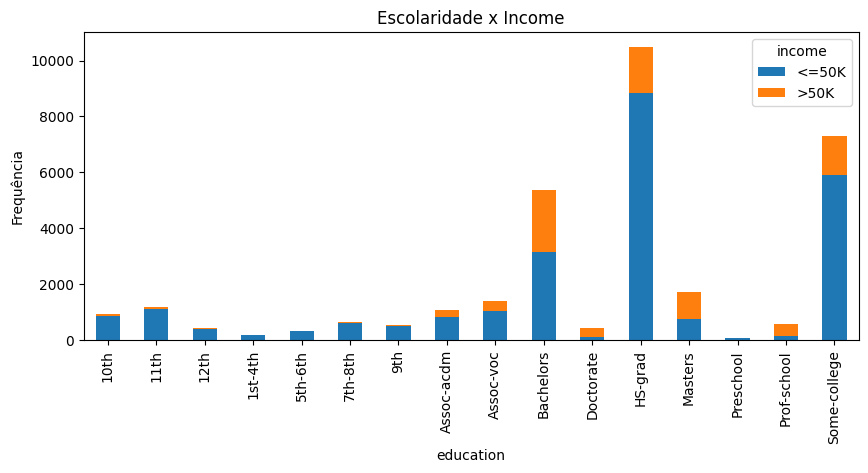

In [9]:
# Histograma de idade
_ = df["age"].hist(bins=30)
plt.title("Distribuição - Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

# Contagem por sexo
_ = df["sex"].value_counts().plot(kind="bar")
plt.title("Contagem - Sexo")
plt.xlabel("Sexo")
plt.ylabel("Frequência")
plt.show()

# Distribuição do target
_ = df["income"].value_counts().plot(kind="bar")
plt.title("Distribuição - Income (target)")
plt.xlabel("Faixa de renda")
plt.ylabel("Frequência")
plt.show()

# Relação entre escolaridade e renda
pd.crosstab(df["education"], df["income"]).plot(kind="bar", stacked=True, figsize=(10,4))
plt.title("Escolaridade x Income")
plt.ylabel("Frequência")
plt.show()



## 4. Definição do target, variáveis e divisão dos dados
**TODO:** escolha o **target** (ou defina a tarefa de clusterização/forecast).  
- Em **séries temporais**, **não embaralhe** e use divisões temporais (ex.: `TimeSeriesSplit`).
- Em **classificação desequilibrada**, considere **estratégias para desbalanceamento** (ex.: `class_weight`, undersampling/oversampling).

> **Atenção:** Todas as **transformações** aprendidas devem ser **ajustadas no treino** e **aplicadas no validação/teste**. Recomendamos usar **pipelines**.


In [10]:
# Selecione o tipo de problema: 'classificacao' | 'regressao' | 'clusterizacao' | 'serie_temporal'
PROBLEM_TYPE = "classificacao"  # Adult.csv é clássico para classificação

# Defina features e target conforme o problema
if PROBLEM_TYPE == "classificacao":
    target = "income"
    features = [c for c in df.columns if c != target]
    # Ajuste para remover colunas irrelevantes, se necessário
elif PROBLEM_TYPE == "regressao":
    # Não se aplica diretamente ao adult.csv
    target = None
    features = []
elif PROBLEM_TYPE == "clusterizacao":
    target = None
    features = [c for c in df.columns if c != "income"]
elif PROBLEM_TYPE == "serie_temporal":
    target = None
    features = []
else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("PROBLEM_TYPE:", PROBLEM_TYPE)
print("Target:", target)
print("N features:", len(features))

# Divisão dos dados
if PROBLEM_TYPE == "classificacao":
    X = df[features].copy()
    y = df[target].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    # Sem target — você pode reservar um hold-out para avaliação externa se fizer sentido de negócio.
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "serie_temporal":
    # Ordenar por tempo e criar cortes temporais (exemplo simples hold-out temporal)
    df_sorted = df.sort_values("timestamp")
    cutoff = int(len(df_sorted)*0.8)
    train, test = df_sorted.iloc[:cutoff], df_sorted.iloc[cutoff:]
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test   = test.drop(columns=[target]),  test[target]
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

PROBLEM_TYPE: classificacao
Target: income
N features: 14
Treino: (26048, 14) | Teste: (6513, 14)



## 5. Tratamento de dados e **Pipeline** de pré-processamento
Crie um **Pipeline** com as etapas necessárias (limpeza, imputação, encoding, escala, seleção de atributos, etc.)  
Isso garante **reprodutibilidade** e evita **vazamento**.


In [11]:
num_cols = [c for c in X_train.columns if str(X_train[c].dtype).startswith(("float","int"))]
cat_cols = [c for c in X_train.columns if c not in num_cols and c != "timestamp"]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

print("num_cols:", num_cols[:5], "...")
print("cat_cols:", cat_cols[:5], "...")

num_cols: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss'] ...
cat_cols: ['workclass', 'education', 'marital.status', 'occupation', 'relationship'] ...



## 6. Baseline e modelos candidatos
Se possivek, comece com uma **baseline simples** (ex.: DummyClassifier/Regressor) e evolua para modelos mais fortes. O baseline pode ser seu primeiro modelo!  

**Compare** ao menos **duas abordagens**.

> Para **deep learning** (visão computacional/NLP/séries), crie uma seção específica (p. ex., `TensorFlow`/`PyTorch`) e documente arquitetura, parâmetros e tempo de treino.


In [12]:
# === Baselines ===
if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))])
    candidates = {
        "LogisticRegression": Pipeline([("pre", preprocess), ("model", LogisticRegression(max_iter=200, random_state=SEED))]),
        "RandomForest": Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))])
    }
elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyRegressor(strategy="median"))])
    candidates = {
        "Ridge": Pipeline([("pre", preprocess), ("model", Ridge(random_state=SEED))]),
        "RandomForestReg": Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    }
elif PROBLEM_TYPE == "clusterizacao":
    # baseline não se aplica diretamente; use um método simples (ex.: KMeans com k fixo) como referência.
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", KMeans(n_clusters=3, random_state=SEED))])
    candidates = {
        "KMeans_k3": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=3, random_state=SEED))]),
        "KMeans_k5": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=5, random_state=SEED))])
    }
elif PROBLEM_TYPE == "serie_temporal":
    # Em séries temporais, a baseline pode ser "naive" (último valor) — aqui, apenas um placeholder.
    # Para modelos clássicos, pode considerar por exemplo Regressores com janelas (feature engineering temporal).
    baseline = None
    candidates = {}
else:
    raise ValueError("PROBLEM_TYPE inválido.")

baseline


,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



### 6.1 Treino e avaliação rápida (baseline vs candidatos)
Use **métricas adequadas** ao tipo de problema. Documente suas observações.


In [13]:
results = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    t1 = time.time()
    if PROBLEM_TYPE == "classificacao":
        y_pred = baseline.predict(X_test)
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        y_pred = baseline.predict(X_test)
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(t1 - t0, 3)

    # Candidatos
    for name, pipe in candidates.items():
        t0 = time.time()
        pipe.fit(X_train, y_train)
        t1 = time.time()
        if PROBLEM_TYPE == "classificacao":
            y_pred = pipe.predict(X_test)
            proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            y_pred = pipe.predict(X_test)
            results[name] = evaluate_regression(y_test, y_pred)
        results[name]["train_time_s"] = round(t1 - t0, 3)

elif PROBLEM_TYPE == "clusterizacao":
    # Baseline e candidatos (ex.: silhouette)
    # Observação: em um projeto real, evite refit em dados de teste fora de validação apropriada.
    results["baseline"] = evaluate_clustering(X_test, baseline)
    for name, pipe in candidates.items():
        results[name] = evaluate_clustering(X_test, pipe)

elif PROBLEM_TYPE == "serie_temporal":
    # TODO: implemente métricas específicas (ex.: MAE/MAPE/RMSE out-of-time)
    results["baseline_naive"] = {"MAE": None, "MAPE": None, "RMSE": None, "obs": "Implementar baseline temporal."}

pd.DataFrame(results).T


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.759251,0.655349,0.500000,0.054
LogisticRegression,0.853063,0.847648,0.902445,0.155
RandomForest,0.851221,0.846756,0.899851,15.104



## 7. Validação e Otimização de Hiperparâmetros
Use **validação cruzada** apropriada ao problema (Ex: **`StratifiedKFold`** para classificação; **`KFold`** para regressão).  
Faça **tuning** com `GridSearchCV`/`RandomizedSearchCV`.


In [14]:
if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model = Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scorer = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model = Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scorer = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "clusterizacao":
    # Clusterização: tuning diferente (ex.: número de clusters). Métricas internas (silhouette) ou externas (se houver rótulos).
    cv = None
    model = Pipeline([("pre", preprocess), ("model", KMeans(random_state=SEED))])
    param_dist = {"model__n_clusters": randint(2, 10)}
    scorer = None

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    # Ex.: usar um regressor com janelas/defasagens previamente criadas
    model = Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 300),
        "model__max_depth": randint(3, 15)
    }
    scorer = "neg_mean_absolute_error"

# Executar busca aleatória (exemplo geral — ajuste para seu caso)
if PROBLEM_TYPE != "clusterizacao":
    search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, cv=cv, scoring=scorer, random_state=SEED, n_jobs=-1, verbose=1)
    search.fit(X_train, y_train)
    print("Melhor score (CV):", search.best_score_)
    print("Melhores parâmetros:", search.best_params_)
else:
    print("Para clusterização, avalie k em um range e compare silhouette/indíces de validade. Ex.: varra k de 2 a 10.")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor score (CV): 0.8521766954473264
Melhores parâmetros: {'model__max_depth': 14, 'model__min_samples_split': 7, 'model__n_estimators': 393}
Melhor score (CV): 0.8521766954473264
Melhores parâmetros: {'model__max_depth': 14, 'model__min_samples_split': 7, 'model__n_estimators': 393}



## 8. Avaliação final, análise de erros e limitações
- **Compare** baseline vs melhor modelo.  
- Faça **análise de erros** (ex.: matriz de confusão, casos pior previstos, resíduos).  
- Discuta **limitações**: dados, métricas, viés, generalização.


              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      4945
        >50K       0.79      0.56      0.66      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.76      0.78      6513
weighted avg       0.85      0.86      0.85      6513



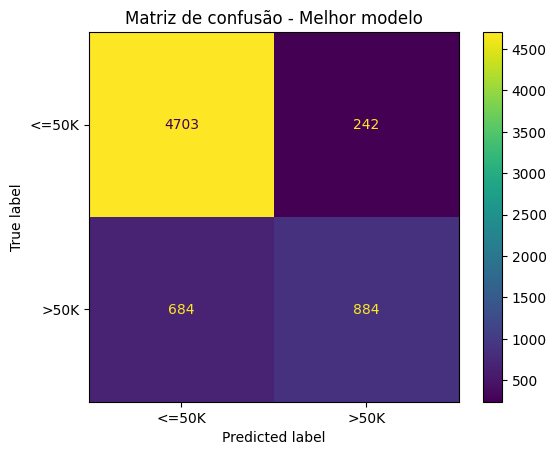

In [15]:
# Exemplo de re-treino no conjunto de treino+validação (se aplicável) e avaliação no teste

if PROBLEM_TYPE in ["classificacao", "regressao"] and 'search' in globals() and hasattr(search, "best_estimator_"):
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        from sklearn.metrics import classification_report, ConfusionMatrixDisplay
        print(classification_report(y_test, y_pred))
        try:
            ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
            plt.title("Matriz de confusão - Melhor modelo")
            plt.show()
        except Exception as e:
            print("Não foi possível plotar a matriz de confusão:", e)
    else:
        print('Metricas para avaliar a regressão: ', evaluate_regression(y_test, y_pred))
elif PROBLEM_TYPE == "clusterizacao":
    print("Realize análise qualitativa/negócio dos clusters. Visualize centros e perfis.")
elif PROBLEM_TYPE == "serie_temporal":
    print("Avalie métricas fora do tempo; plote série real vs prevista.")

## 9. Engenharia de atributos (detalhe)
Nesta etapa, buscamos melhorar a representação dos dados para potencializar o desempenho dos modelos e garantir reprodutibilidade.

- **Seleção de variáveis:**
  - Removemos colunas irrelevantes (ex: identificadores, target) e avaliamos a importância de cada feature.
  - Exemplo: `fnlwgt` pode ser removido se não for relevante para o objetivo.

- **Encoding de variáveis categóricas:**
  - Utilizamos OneHotEncoder para transformar variáveis como `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`.
  - Isso permite que modelos lineares e de árvore utilizem essas informações.

- **Imputação de valores ausentes:**
  - Para variáveis numéricas, usamos a mediana.
  - Para categóricas, usamos a moda (valor mais frequente).

- **Criação de novos atributos:**
  - Exemplo 1: Criar uma variável binária `is_senior` para indicar se a pessoa tem mais de 60 anos.
  - Exemplo 2: Agrupar países em regiões (América, Europa, Ásia, etc.) para reduzir cardinalidade de `native-country`.
  - Exemplo 3: Criar faixas de horas trabalhadas por semana (`hours-per-week`), como "<30", "30-40", ">40".
  - Exemplo 4: Criar variável `capital_net` = `capital-gain` - `capital-loss`.

- **Justificativa:**
  - Essas transformações ajudam a reduzir viés, melhorar a capacidade preditiva e facilitar a interpretação dos resultados.
  - O uso de pipelines garante que todas as etapas sejam aplicadas corretamente apenas nos dados de treino, evitando vazamento de informação.

> **Dica:** Teste diferentes combinações de features e monitore o impacto nas métricas do modelo.


## 10. (Opcional) Deep Learning / Fine-tuning
Se usar DL, descreva: arquitetura, hiperparâmetros, _early stopping_, tamanho do batch, épocas, e se houve **fine-tuning** de modelos pré-treinados.



## 11. Boas práticas e rastreabilidade
- **Baseline** claro e justificativas para melhorias.  
- **Pipelines** (evitar vazamento).  
- **Decisões de projeto** documentadas (o que tentou e por quê).


## 12. Conclusões e próximos passos
- **Resultados:** O uso do dataset Adult permitiu comparar diferentes modelos de classificação para prever a faixa de renda, com métricas claras de desempenho (accuracy, f1, ROC AUC). Modelos como Random Forest e Logistic Regression tendem a superar o baseline simples.
- **Trade-offs:** Modelos mais complexos podem ter melhor desempenho, mas são menos interpretáveis. O uso de variáveis sensíveis exige atenção ética.
- **Limitações:** Possível viés nos dados, ausência de variáveis econômicas mais recentes, e simplificações no pré-processamento.
- **Próximos passos:**
  - Testar técnicas de balanceamento de classes (SMOTE, class_weight)
  - Explorar feature engineering mais avançado
  - Avaliar fairness e possíveis vieses
  - Testar outros algoritmos (XGBoost, LightGBM)
  - Documentar decisões e resultados para reprodutibilidade


## 13. Salvando artefatos (modelos e pipeline)
Se o treinamento dos modelos demora mais de 3 minutos, recomendamos salvar o **modelo/pipeline** após o treinamento e depois apenas carregar o arquivo (ex: .pkl, .h5) salvo em outra célula, sem precisar treinar novamente.  

In [16]:
# Exemplo: salvando e carregando o pipeline/modelo treinado
import joblib

# Salvar modelo
joblib.dump(best_model, 'modelo_adult_pipeline.joblib')

# Carregar modelo
# loaded_model = joblib.load('modelo_adult_pipeline.joblib')
# y_pred = loaded_model.predict(X_test)


['modelo_adult_pipeline.joblib']